In [12]:
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

In [14]:
hbar = 1
#1.054571817 * 10**(-34)

def comutator(A, B):
    A = A.to(torch.complex128)
    B = B.to(torch.complex128)
    return A@B-B@A
def anticomutator(A, B):
    A = A.to(torch.complex128)
    B = B.to(torch.complex128)
    return A@B+B@A
def lindbladOp(L, rho):
    L = L.to(torch.complex64)
    rho = rho.to(torch.complex64)
    L_dag = L.conj().transpose(0,1)
    return L @ rho @ L_dag - 0.5 * anticomutator(L_dag @ L, rho)
def FixRho(rho):
    # 1. Hermitowskość
    rho_dag = rho.conj().transpose(1, 2)
    rho = (rho + rho_dag) / 2

    # 2. Diagonalizacja batchowa
    eigvals, eigvecs = torch.linalg.eigh(rho)

    # 3. Ucięcie ujemnych wartości własnych
    eigvals = torch.clamp(eigvals, min=0)

    # 4. Rekonstrukcja macierzy
    D = torch.zeros_like(rho)

    D[:, 0, 0] = eigvals[:, 0]
    D[:, 1, 1] = eigvals[:, 1]

    eigvecs_dag = eigvecs.conj().transpose(1, 2)

    rho_fixed = eigvecs @ D @ eigvecs_dag

    # 5. Normalizacja śladu
    trace = rho_fixed.diagonal(dim1=1, dim2=2).sum(dim=1, keepdim=True)

    rho_fixed = rho_fixed / trace.unsqueeze(-1)

    return rho_fixed
def plot_signals(signals, t_axis = None, labels=None, points=None, pointlabels=None):
    fig, ax = plt.subplots()
    for s, sig in enumerate(signals):
        if t_axis is None:
            t_axis = np.linspace(0.,1., num=len(sig), endpoint=True)
        ax.plot(t_axis, sig, label=labels[s])
    if points is not None:
        for p, pts in enumerate(points):
            ax.scatter(pts[0], pts[1], marker='x', label=pointlabels[p])
    if labels is not None or pointlabels is not None: ax.legend()
    plt.show()

In [16]:
class Lindblad_solver:

    def __init__(self, t1, t2, dt):
        self.dt = dt
        self.t1 = t1
        self.t2 = t2

        g1 = 1/t1
        g2 = 1/t2

        L1 = torch.tensor(np.array([
            [0,  1],
            [0, 0]
        ], dtype=complex)*np.sqrt(g1))

        L2 = torch.tensor(np.array([
            [1,  0],
            [0, -1]
        ], dtype=complex)*np.sqrt(g2))

        self.H = torch.tensor(np.array([
            [0,  0],
            [0, 0]
        ], dtype=complex))

        
        self.L_list = [L1, L2]

    def EvoOp(self, rho):
        op = -1j/hbar*comutator(self.H, rho)
        for Li in self.L_list:
            op += lindbladOp(Li,rho)
        return op

    def step(self, rho0):
        k1 = self.EvoOp(rho0)
        k2 = self.EvoOp(rho0 + dt/2 * k1)
        k3 = self.EvoOp(rho0 + dt/2 * k2)
        k4 = self.EvoOp(rho0 + dt * k3)

        

        rho_next = rho0 + dt/6 * (k1 + 2*k2 + 2*k3 + k4)


        rho_next = FixRho(rho_next)

        

        return rho_next

    
    def run_simulation(self, rho0, time=1000):
        states = [rho0.clone()]
        times = [0]
        rho_curr = rho0
        
        no_steps = int(time/self.dt)
        
        # iterate subseqent time-steps
        for i in range(no_steps):
            rho_curr = self.step(rho_curr)
            times.append((i + 1) * dt)
            states.append(rho_curr.clone())

        return [np.array(times), np.array(states)]

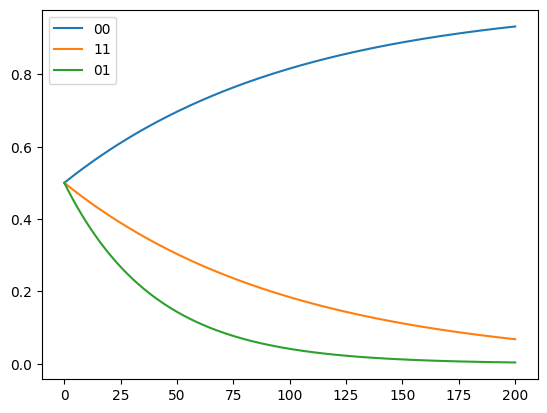

In [18]:
# let's start with numerical solution
dt = 1 #0.01ps
time = 200
solver = Lindblad_solver(100, 100, dt)

psi0 = np.array([1, 1], dtype=complex)
psi0 /= np.linalg.norm(psi0)

psi0 = torch.tensor(psi0, dtype=torch.complex64)

rho0 = torch.outer(psi0, psi0.conj()).unsqueeze(0)

[times, states] = solver.run_simulation(rho0, time)
#print(times)

states = states[:, 0, :, :]
plot_signals([np.abs(states[:, 0, 0]), np.abs(states[:, 1, 1]), np.abs(states[:, 0, 1])],
                  labels = ['00', '11', '01'],
                  t_axis = times)

In [22]:
# define NN estimator
def build_mlp(layer_sizes=[1,256,128,64,32,3], regularization=None, activation='tanh', output='linear', dropout_rate=0.2):

    layers = []
    for i in range(len(layer_sizes) - 2):
        linear_layer = nn.Linear(layer_sizes[i], layer_sizes[i+1])

        # assign most suitable initialization for activation functions
        if activation == 'relu':
            nn.init.kaiming_normal_(linear_layer.weight,
                                    mode='fan_in', nonlinearity='relu')
        elif activation == 'tanh':
            nn.init.xavier_uniform_(linear_layer.weight)
        else:
            nn.init.kaiming_normal_(linear_layer.weight,
                                    mode='fan_in', nonlinearity='leaky_relu')
        # Add the initialized linear layer to the model
        layers.append(linear_layer)

        if regularization == 'batch_normalization':
            layers.append(nn.BatchNorm1d(layer_sizes[i+1]))
        elif regularization == 'dropout':
            layers.append(nn.Dropout(p=dropout_rate))

        if activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'tanh':
            layers.append(nn.Tanh())
        else:
            layers.append(nn.LeakyReLU())

    linear_layer = nn.Linear(layer_sizes[-2], layer_sizes[-1])
    nn.init.xavier_uniform_(linear_layer.weight)
    layers.append(linear_layer)
    if output == 'lrelu':
        layers.append(nn.LeakyReLU())
    elif output == 'tanh':
        layers.append(nn.Tanh())
    #layers.append(nn.Softmax(dim=1))
    model = nn.Sequential(*layers)
    return model


class NN_solver:

    def __init__(self, predictor, solver, data, collocation_points):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.predictor = predictor.to(self.device)
        self.solver = solver
        self.data_points = torch.from_numpy(data[0]).to(torch.float32).view(-1,1).to(self.device)
        self.data_values = torch.from_numpy(data[1]).to(torch.float32).view(-1,2,2).to(self.device)
        self.collocation_points = torch.from_numpy(collocation_points).to(torch.float32).view(-1,1).requires_grad_(True).to(self.device)

    def decode_rho(self, out):
        rho = torch.zeros(out.shape[0], 2, 2, dtype=out.dtype, device=out.device)

        rho[:, 0, 0] = out[:, 0]
        rho[:, 0, 1] = out[:, 1] + 1j * out[:, 2]
        rho[:, 1, 0] = out[:, 1] - 1j * out[:, 2]
        rho[:, 1, 1] = 1 - out[:, 0]

        return rho

    def f_nn(self, t):
        # compare prediction obrained using solver and direct nn prediction for t+1

        out0 = self.predictor(t)
        out_nn = self.predictor(t + self.solver.dt)

        rho0 = self.decode_rho(out0)

        rho_nn = self.decode_rho(out_nn)

        rho_sol = self.solver.step(rho0)
        
        return self.Rho_diff(rho_nn, rho_sol)

    def f_nn0(self, t):
        #dt = self.solver.dt
        dt = 0.01
        t = t * self.solver.dt
        tp = t+dt
        tm = t-dt
        i = self.predictor(t)
        ip = self.predictor(tp)
        im = self.predictor(tm)
        didt = (ip - im)/dt/2.
        di2dt2 = (ip - i*2. + im)/dt/dt
        return di2dt2+didt*.1+i
        #return di2dt2 + didt*self.solver.R/self.L(i, *self.solver.params) + i/self.solver.C/self.L(i, *self.solver.params)

    def f_nn1(self, t):
        out = self.predictor(t)
        doutdt = self.grad(out, t)[0]
        print(doutdt)

        rho = self.decode_rho(out[:, 0], out[:, 1], out[:, 2])
        drhodt = self.decode_rho(doutdt[:, 0], doutdt[:, 1], doutdt[:, 2])
        return self.Rho_diff(EvoOp(rho), drhodt)

    def grad(self, outputs, inputs):
        """Computes the partial derivative of
        an output with respect to an input."""
        return torch.autograd.grad(
            outputs,
            inputs,
            grad_outputs=torch.ones_like(outputs),
            create_graph=True
        )

    def make_predictions(self, t):
        t = torch.from_numpy(t).to(torch.float32).view(-1,1).to(self.device)
        pred = self.decode_rho(self.predictor(t)).cpu().detach().numpy()
        return pred

    def Rho_diff(self, rho1, rho2):
        rho_diff = rho1 - rho2
        return torch.sum(torch.abs(rho_diff), dim=(1,2))
        


class Training:

    def __init__(self, nn_solver, no_epochs, lr, physics_loss=True):
        self.nn_solver = nn_solver
        self.no_epochs = no_epochs
        self.datalossF = nn.MSELoss()
        self.physics_loss = physics_loss
        self.optimizer = torch.optim.Adam(self.nn_solver.predictor.parameters(), lr=lr)

    def training_loop(self):

        store_loss = []
        for epoch in range(self.no_epochs):
            self.nn_solver.predictor.train()
            self.optimizer.zero_grad()
            
            physicsL = self.nn_solver.f_nn(self.nn_solver.collocation_points).square().sum()

            out_pred = self.nn_solver.predictor(self.nn_solver.data_points*self.nn_solver.solver.dt)
            rho_pred = self.nn_solver.decode_rho(out_pred)
            rho_data = self.nn_solver.data_values
            dataL = self.nn_solver.Rho_diff(rho_pred, rho_data).square().sum()
            loss = dataL*len(self.nn_solver.collocation_points)
            if self.physics_loss:
                loss += physicsL
            loss.backward()
            self.optimizer.step()
            store_loss.append(loss.item())

            if epoch % 1000 == 0:
                print(f"Epoch [{epoch}/{self.no_epochs}], Data Loss: {dataL:.5f}, Physics Loss: {physicsL:.5f}")

        #self.plot_prediction()
        plt.plot(store_loss[500:])
        plt.yscale('log')
        plt.title('Loss')
        plt.show()

In [24]:
# now define PINN solver
data_indices = np.array([0,10,50,100,150])
data_times = times[data_indices]
data_values = states[data_indices]
no_collocation_points = 100
collocation_points_times = np.sort(np.random.uniform(np.min(times), np.max(times), no_collocation_points))


solver_nn = NN_solver(predictor=build_mlp(),
                               solver=solver,
                               data=[data_times, data_values],
                               collocation_points=collocation_points_times)

# train NN predictor
train_nn = Training(solver_nn, no_epochs=5000, lr=1.e-3, physics_loss=True)

C:\Users\Ziemowit\AppData\Local\Temp\ipykernel_8004\4139937989.py:51: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Copy.cpp:308.)
  self.data_values = torch.from_numpy(data[1]).to(torch.float32).view(-1,2,2).to(self.device)


Epoch [0/5000], Data Loss: 19.25943, Physics Loss: 11.71172
Epoch [1000/5000], Data Loss: 0.00000, Physics Loss: 0.01572
Epoch [2000/5000], Data Loss: 0.00000, Physics Loss: 0.00216
Epoch [3000/5000], Data Loss: 0.00000, Physics Loss: 0.00044
Epoch [4000/5000], Data Loss: 0.00000, Physics Loss: 0.00157


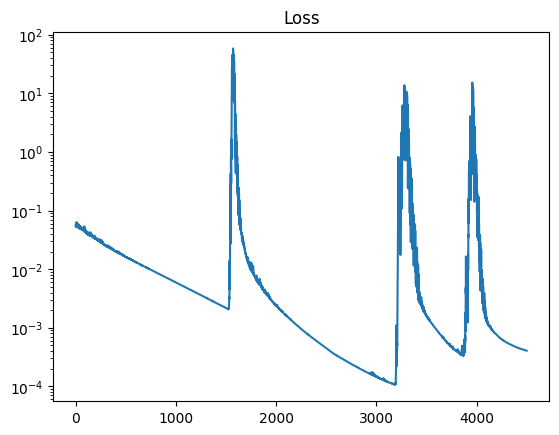

In [149]:
train_nn.training_loop()

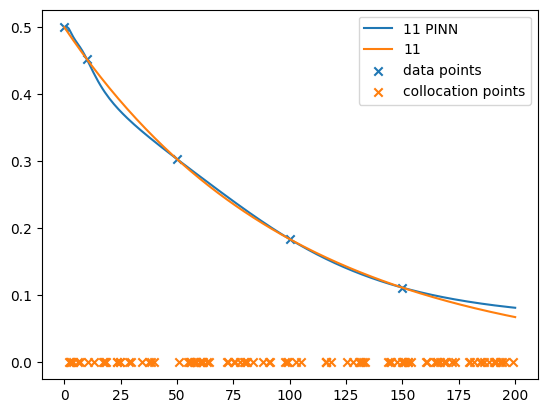

In [155]:
no_timesteps = int(time/dt)
times_nn = np.linspace(0.,time, num=no_timesteps+1, endpoint=True)
pred_PINN = solver_nn.make_predictions(times_nn)
#plot_signals([np.abs(states[:, 0, 0]), np.abs(states[:, 0, 1]), np.abs(pred_PINN[:, 0, 0]), np.abs(pred_PINN[:, 0, 1])],
#                  labels = ['00', '01', '00 PINN', '01 PINN'],
#                  t_axis = times_nn)


#plot_signals([np.abs(states[:, 0, 0]), np.abs(states[:, 0, 1])],
#                  labels = ['00', '01'],
#                  t_axis = times)
plot_signals([np.abs(pred_PINN[:, 1, 1]), np.abs(states[:, 1, 1])],
             labels = ['11 PINN', '11'],
             t_axis = times_nn,
             points = [[data_times, data_values[:, 1, 1]], [collocation_points_times, np.zeros(len(collocation_points_times))]],
             pointlabels = ['data points', 'collocation points'])